In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List


# === PREPROCESAMIENTO ===

def load_img_g(ruta_imagen: str, tamaño: Tuple[int, int] = (128, 128)) -> np.ndarray:
    """Carga imagen, convierte a escala de grises y redimensiona."""
    imagen = Image.open(ruta_imagen).convert('L')
    imagen = imagen.resize(tamaño)
    return np.array(imagen)


def bin_img(matriz: np.ndarray, umbral: int = 128) -> np.ndarray:
    """Convierte una imagen en escala de grises a binaria."""
    return (matriz > umbral).astype(np.uint8)


# === POSTPROCESAMIENTO ===

def mat_to_img(matriz: np.ndarray, binaria: bool = True) -> Image.Image:
    """Convierte una matriz binaria o de grises a imagen PIL."""
    if binaria:
        matriz = (matriz * 255).astype(np.uint8)
    return Image.fromarray(matriz)


# === VISUALIZACIÓN ===

def mostrar_imagenes(imagenes: List[np.ndarray], titulos: List[str]) -> None:
    """Muestra una lista de imágenes con sus títulos."""
    plt.figure(figsize=(5 * len(imagenes), 5))
    for i, (img, titulo) in enumerate(zip(imagenes, titulos), start=1):
        plt.subplot(1, len(imagenes), i)
        plt.imshow(img, cmap='gray')
        plt.title(titulo)
        plt.axis('off')
    plt.tight_layout()
    plt.show()



In [2]:
# === SERIALIZACIÓN ===
def mat_to_binstr(matriz: np.ndarray) -> str:
    """Convierte matriz binaria 2D en cadena binaria."""
    matriz_bin = (matriz > 0).astype(np.uint8)
    return ''.join(matriz_bin.flatten().astype(str))

def binstr_to_mat(cadena: str, shape: Tuple[int, int]) -> np.ndarray:
    assert len(cadena) == shape[0] * shape[1], "Longitud cadena no coincide con forma"
    arr = np.array(list(cadena), dtype=np.uint8)
    return arr.reshape(shape)


1111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111

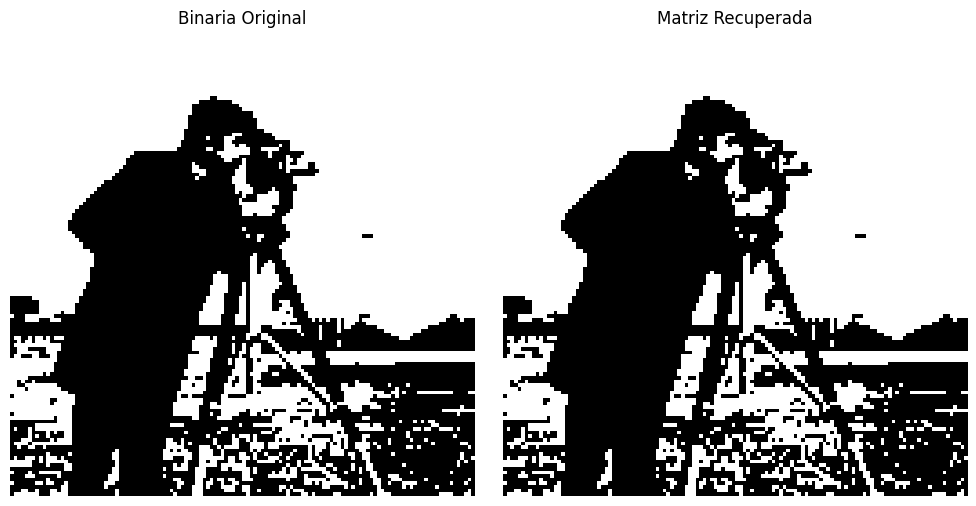

In [3]:
if __name__ == "__main__":
    ruta = "./Test Images/cameraman.jpg"
    gris = load_img_g(ruta)
    binaria = bin_img(gris)

    stringgg = mat_to_binstr(binaria)
    print(f"{stringgg[:]}...")

    matriz_recuperada = binstr_to_mat(stringgg, binaria.shape)

    mostrar_imagenes([binaria, matriz_recuperada], ["Binaria Original", "Matriz Recuperada"])
